In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
file_path = "../data/raw/skill_builder_data.csv"

encodings = ['utf-8', 'utf-8-sig', 'cp1252', 'latin-1']
for enc in encodings:
    try:
        df = pd.read_csv(file_path, encoding=enc)
        print(f"Loaded with encoding: {enc}")
        break
    except Exception as e:
        print(f"Failed with encoding {enc}: {type(e).__name__}: {e}")
else:
    import io
    with open(file_path, 'rb') as f:
        data = f.read().decode('utf-8', errors='replace')
    df = pd.read_csv(io.StringIO(data))
    print("Loaded by decoding with errors='replace'")

print("Dataset loaded successfully.")
print("Dataset shape:", df.shape)

Failed with encoding utf-8: UnicodeDecodeError: 'utf-8' codec can't decode bytes in position 5-6: invalid continuation byte
Failed with encoding utf-8-sig: UnicodeDecodeError: 'utf-8' codec can't decode bytes in position 98782-98783: invalid continuation byte
Loaded with encoding: cp1252
Dataset loaded successfully.
Dataset shape: (525534, 30)


C:\Users\user_\AppData\Local\Temp\ipykernel_29988\3576830209.py:6: DtypeWarning: Columns (0: skill_name) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path, encoding=enc)


In [3]:
df.head()

,order_id,assignment_id,user_id,assistment_id,problem_id,original,correct,attempt_count,ms_first_response,tutor_mode,...,hint_count,hint_total,overlap_time,template_id,answer_id,answer_text,first_action,bottom_hint,opportunity,opportunity_original
0,33022537,277618,64525,33139,51424,1,1,1,32454,tutor,...,0,3,32454,30799,NaN,26,0,NaN,1,1.0
1,33022709,277618,64525,33150,51435,1,1,1,4922,tutor,...,0,3,4922,30799,NaN,55,0,NaN,2,2.0
2,35450204,220674,70363,33159,51444,1,0,2,25390,tutor,...,0,3,42000,30799,NaN,88,0,NaN,1,1.0
3,35450295,220674,70363,33110,51395,1,1,1,4859,tutor,...,0,3,4859,30059,NaN,41,0,NaN,2,2.0
4,35450311,220674,70363,33196,51481,1,0,14,19813,tutor,...,3,4,124564,30060,NaN,65,0,0.0,3,3.0


In [4]:
print("Total columns:", len(df.columns))
print("\nColumn names:")
for col in df.columns:
    print(col)

Total columns: 30

Column names:
order_id
assignment_id
user_id
assistment_id
problem_id
original
correct
attempt_count
ms_first_response
tutor_mode
answer_type
sequence_id
student_class_id
position
type
base_sequence_id
skill_id
skill_name
teacher_id
school_id
hint_count
hint_total
overlap_time
template_id
answer_id
answer_text
first_action
bottom_hint
opportunity
opportunity_original


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 525534 entries, 0 to 525533
Data columns (total 30 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              525534 non-null  int64  
 1   assignment_id         525534 non-null  int64  
 2   user_id               525534 non-null  int64  
 3   assistment_id         525534 non-null  int64  
 4   problem_id            525534 non-null  int64  
 5   original              525534 non-null  int64  
 6   correct               525534 non-null  int64  
 7   attempt_count         525534 non-null  int64  
 8   ms_first_response     525534 non-null  int64  
 9   tutor_mode            525534 non-null  str    
 10  answer_type           525534 non-null  str    
 11  sequence_id           525534 non-null  int64  
 12  student_class_id      525534 non-null  int64  
 13  position              525534 non-null  int64  
 14  type                  525534 non-null  str    
 15  base_sequen

In [6]:
missing_values = df.isnull().sum().sort_values(ascending=False)

print("Missing values by column:")
print(missing_values)

Missing values by column:
answer_id               476856
bottom_hint             445627
answer_text              94784
skill_name               78690
opportunity_original     76314
skill_id                 66326
correct                      0
attempt_count                0
order_id                     0
assignment_id                0
user_id                      0
assistment_id                0
problem_id                   0
original                     0
position                     0
student_class_id             0
sequence_id                  0
answer_type                  0
tutor_mode                   0
ms_first_response            0
base_sequence_id             0
type                         0
hint_total                   0
hint_count                   0
school_id                    0
teacher_id                   0
overlap_time                 0
template_id                  0
first_action                 0
opportunity                  0
dtype: int64


In [7]:
important_columns = [
    "order_id",
    "assignment_id",
    "user_id",
    "problem_id",
    "correct",
    "attempt_count",
    "skill_id",
    "skill_name",
    "hint_count",
    "hint_total",
    "ms_first_response",
    "opportunity"
]

available_columns = [col for col in important_columns if col in df.columns]

memory_df = df[available_columns].copy()

print("Selected columns:")
print(memory_df.columns.tolist())

memory_df.head()

Selected columns:
['order_id', 'assignment_id', 'user_id', 'problem_id', 'correct', 'attempt_count', 'skill_id', 'skill_name', 'hint_count', 'hint_total', 'ms_first_response', 'opportunity']


,order_id,assignment_id,user_id,problem_id,correct,attempt_count,skill_id,skill_name,hint_count,hint_total,ms_first_response,opportunity
0,33022537,277618,64525,51424,1,1,1.0,Box and Whisker,0,3,32454,1
1,33022709,277618,64525,51435,1,1,1.0,Box and Whisker,0,3,4922,2
2,35450204,220674,70363,51444,0,2,1.0,Box and Whisker,0,3,25390,1
3,35450295,220674,70363,51395,1,1,1.0,Box and Whisker,0,3,4859,2
4,35450311,220674,70363,51481,0,14,1.0,Box and Whisker,3,4,19813,3


In [8]:
num_rows = len(memory_df)
num_students = memory_df["user_id"].nunique()
num_problems = memory_df["problem_id"].nunique()
num_skills = memory_df["skill_name"].nunique()

print("Basic Dataset Summary")
print("----------------------")
print("Total interactions:", num_rows)
print("Unique students:", num_students)
print("Unique problems:", num_problems)
print("Unique skills/concepts:", num_skills)

Basic Dataset Summary
----------------------
Total interactions: 525534
Unique students: 4217
Unique problems: 26688
Unique skills/concepts: 110


Correct/Wrong Distribution:
correct
0    168449
1    357085
Name: count, dtype: int64


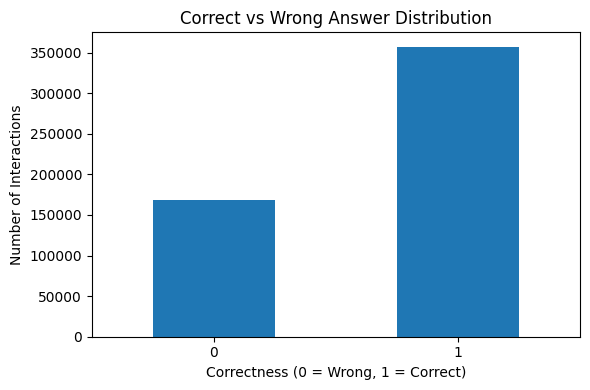

In [9]:
correct_counts = memory_df["correct"].value_counts().sort_index()

print("Correct/Wrong Distribution:")
print(correct_counts)

plt.figure(figsize=(6,4))
correct_counts.plot(kind="bar")
plt.title("Correct vs Wrong Answer Distribution")
plt.xlabel("Correctness (0 = Wrong, 1 = Correct)")
plt.ylabel("Number of Interactions")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [10]:
missing_skill_count = memory_df["skill_name"].isnull().sum()
total_count = len(memory_df)
missing_percentage = (missing_skill_count / total_count) * 100

print("Missing skill_name rows:", missing_skill_count)
print("Missing skill_name percentage:", round(missing_percentage, 2), "%")

Missing skill_name rows: 78690
Missing skill_name percentage: 14.97 %


In [11]:
clean_df = memory_df.dropna(subset=["skill_name"]).copy()

print("Before cleaning:", memory_df.shape)
print("After removing missing skill_name:", clean_df.shape)
print("Removed rows:", memory_df.shape[0] - clean_df.shape[0])

Before cleaning: (525534, 12)
After removing missing skill_name: (446844, 12)
Removed rows: 78690


Top 10 most frequent skills/concepts:
skill_name
Equation Solving Two or Fewer Steps         24253
Percent Of                                  22931
Addition and Subtraction Integers           22895
Conversion of Fraction Decimals Percents    20992
Volume Rectangular Prism                    19489
Venn Diagram                                18275
Volume Cylinder                             13734
Multiplication and Division Integers        13159
Area Rectangle                              12934
Addition and Subtraction Fractions          11334
Name: count, dtype: int64


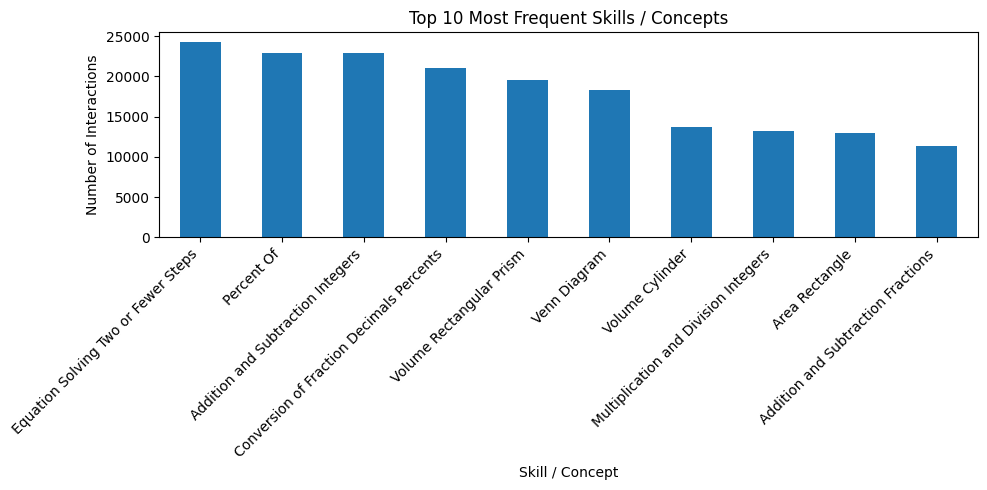

In [12]:
top_skills = clean_df["skill_name"].value_counts().head(10)

print("Top 10 most frequent skills/concepts:")
print(top_skills)

plt.figure(figsize=(10,5))
top_skills.plot(kind="bar")
plt.title("Top 10 Most Frequent Skills / Concepts")
plt.xlabel("Skill / Concept")
plt.ylabel("Number of Interactions")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Student interaction statistics:
count    4151.000000
mean      107.647314
std       274.024986
min         1.000000
25%         9.000000
50%        24.000000
75%        80.000000
max      6157.000000
Name: count, dtype: float64


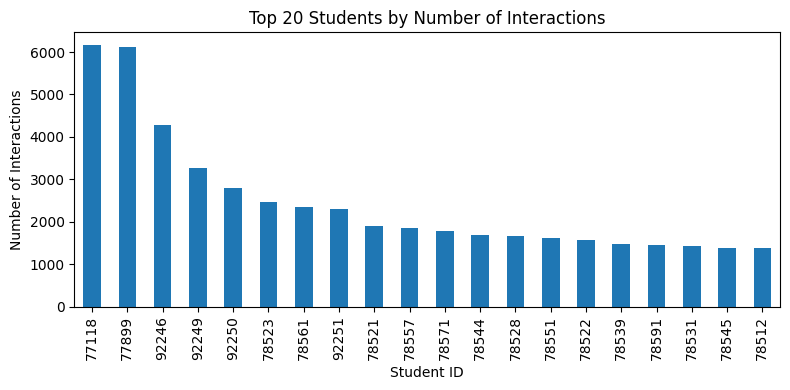

In [13]:
student_interactions = clean_df["user_id"].value_counts()

print("Student interaction statistics:")
print(student_interactions.describe())

plt.figure(figsize=(8,4))
student_interactions.head(20).plot(kind="bar")
plt.title("Top 20 Students by Number of Interactions")
plt.xlabel("Student ID")
plt.ylabel("Number of Interactions")
plt.tight_layout()
plt.show()

In [14]:
summary = {
    "total_raw_interactions": len(memory_df),
    "clean_interactions": len(clean_df),
    "unique_students": clean_df["user_id"].nunique(),
    "unique_problems": clean_df["problem_id"].nunique(),
    "unique_concepts": clean_df["skill_name"].nunique(),
    "missing_skill_rows_removed": memory_df.shape[0] - clean_df.shape[0]
}

summary_df = pd.DataFrame([summary])

os.makedirs("../outputs/tables", exist_ok=True)

summary_df.to_csv("../outputs/tables/dataset_summary.csv", index=False)

summary_df

,total_raw_interactions,clean_interactions,unique_students,unique_problems,unique_concepts,missing_skill_rows_removed
0,525534,446844,4151,16891,110,78690


In [15]:
processed_df = clean_df.rename(columns={
    "order_id": "interaction_order",
    "assignment_id": "session_id",
    "user_id": "student_id",
    "skill_name": "concept_name",
    "ms_first_response": "response_time_ms"
})

processed_columns = [
    "interaction_order",
    "student_id",
    "session_id",
    "problem_id",
    "concept_name",
    "correct",
    "attempt_count",
    "hint_count",
    "hint_total",
    "response_time_ms",
    "opportunity"
]

processed_df = processed_df[processed_columns].copy()

processed_df = processed_df.sort_values(
    by=["student_id", "interaction_order"]
).reset_index(drop=True)

os.makedirs("../data/processed", exist_ok=True)

processed_df.to_csv("../data/processed/processed_interactions.csv", index=False)

print("Processed dataset saved successfully.")
print("Processed dataset shape:", processed_df.shape)

processed_df.head()

Processed dataset saved successfully.
Processed dataset shape: (446844, 11)


,interaction_order,student_id,session_id,problem_id,concept_name,correct,attempt_count,hint_count,hint_total,response_time_ms,opportunity
0,21617623,14,263599,93383,Circle Graph,0,1,2,2,26271,1
1,21617623,14,263599,93383,Percent Of,0,1,2,2,26271,1
2,21617632,14,263599,93407,Circle Graph,1,1,0,2,29123,2
3,21617632,14,263599,93407,Percent Of,1,1,0,2,29123,2
4,21617641,14,263599,93400,Circle Graph,0,1,2,2,13779,3
